In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import SpectralClustering
import time
import os

📝 Создаём тестовое изображение...


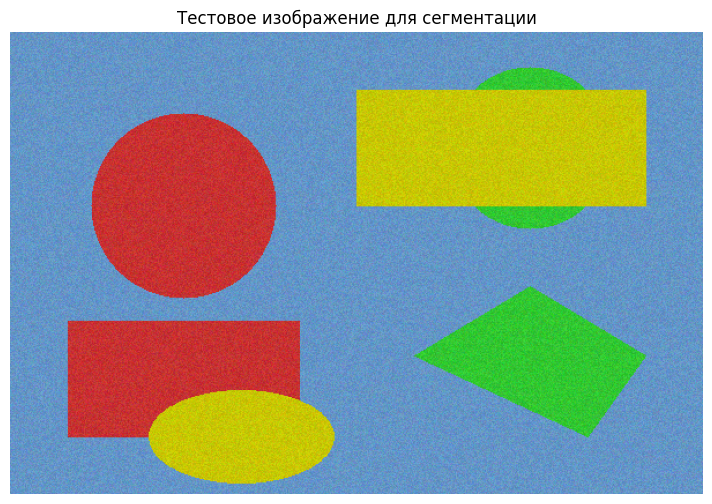

In [12]:
# ===============================
# Создание тестового изображения
# ===============================

def create_segmentation_test_image():
    """Создаёт тестовое изображение для сегментации"""

    print("📝 Создаём тестовое изображение...")

    img = np.zeros((400, 600, 3), dtype=np.uint8)

    # Фон - голубой
    img[:, :] = [200, 150, 100]

    # Красный объект
    cv2.circle(img, (150, 150), 80, (50, 50, 200), -1)
    cv2.rectangle(img, (50, 250), (250, 350), (50, 50, 200), -1)

    # Зелёный объект
    cv2.circle(img, (450, 100), 70, (50, 200, 50), -1)
    points = np.array([[350, 280], [450, 220], [550, 280], [500, 350]], np.int32)
    cv2.fillPoly(img, [points], (50, 200, 50))

    # Жёлтый объект
    cv2.rectangle(img, (300, 50), (550, 150), (0, 200, 200), -1)
    cv2.ellipse(img, (200, 350), (80, 40), 0, 0, 360, (0, 200, 200), -1)

    # Добавляем шум
    noise = np.random.randint(-20, 20, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

img = create_segmentation_test_image()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title('Тестовое изображение для сегментации')
plt.axis('off')
plt.show()

Тестирование silhouette score на тестовом изображении...
📝 Создаём тестовое изображение...
K = 2: Silhouette score = 0.6903
K = 3: Silhouette score = 0.7911
K = 4: Silhouette score = 0.8397
K = 5: Silhouette score = 0.4664
K = 6: Silhouette score = 0.4526


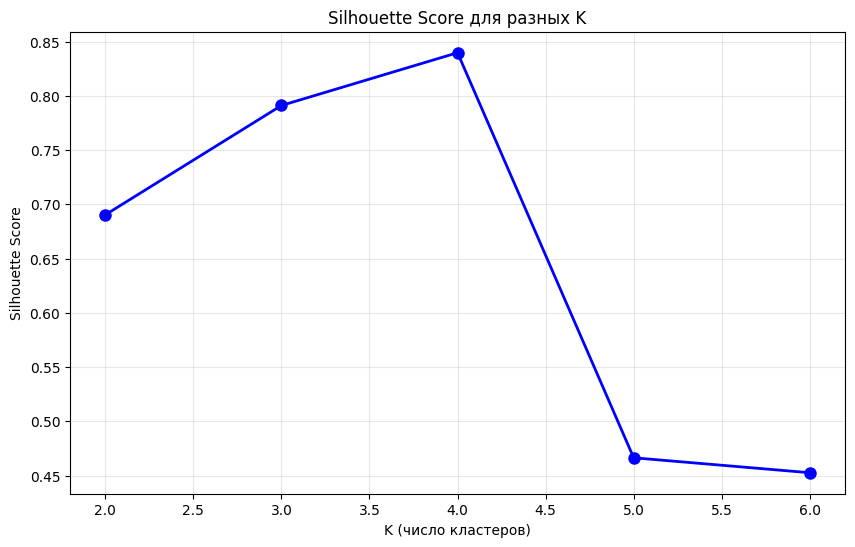

In [19]:
# ========================================
# ЧАСТЬ 1: Реализация метода силуэта (silhouette score)
# ========================================

def silhouette_score_manual(pixels, labels):
    """
    Реализация silhouette score "с нуля"
    """
    n = len(pixels)
    clusters = np.unique(labels)
    k = len(clusters)

    if k == 1:
        return 0.0

    # Преобразуем метки в удобный формат
    label_map = {clusters[i]: i for i in range(k)}
    labels_idx = np.array([label_map[l] for l in labels])

    # Для больших наборов данных используем эффективное вычисление
    from sklearn.metrics.pairwise import euclidean_distances
    sample_size = min(1000, n)

    if n > sample_size:
        indices = np.random.choice(n, sample_size, replace=False)
        pixels_sample = pixels[indices]
        labels_sample = labels_idx[indices]
    else:
        pixels_sample = pixels
        labels_sample = labels_idx

    distances = euclidean_distances(pixels_sample)

    silhouette_values = np.zeros(len(pixels_sample))

    for i in range(len(pixels_sample)):
        cluster_i = labels_sample[i]

        # a(i): среднее расстояние до точек в том же кластере
        same_cluster_mask = (labels_sample == cluster_i)
        same_cluster_mask[i] = False

        if np.sum(same_cluster_mask) > 0:
            a_i = np.mean(distances[i, same_cluster_mask])
        else:
            a_i = 0.0

        # b(i): минимальное среднее расстояние до точек других кластеров
        b_i = np.inf

        for cluster_j in range(k):
            if cluster_j == cluster_i:
                continue

            other_cluster_mask = (labels_sample == cluster_j)

            if np.sum(other_cluster_mask) > 0:
                avg_dist = np.mean(distances[i, other_cluster_mask])
                b_i = min(b_i, avg_dist)

        if b_i == np.inf:
            b_i = a_i

        # Вычисляем silhouette для точки i
        if a_i == 0 and b_i == 0:
            s_i = 0.0
        else:
            s_i = (b_i - a_i) / max(a_i, b_i)

        silhouette_values[i] = s_i

    return np.mean(silhouette_values)

# Тестирование silhouette score на тестовом изображении
print("Тестирование silhouette score на тестовом изображении...")
img = create_segmentation_test_image()
pixels = img.reshape(-1, 3).astype(np.float32)

# Применяем K-Means с разными K и вычисляем silhouette score
K_values = range(2, 7)
silhouette_scores = []

for K in K_values:
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    ret, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    score = silhouette_score_manual(pixels, labels.flatten())
    silhouette_scores.append(score)
    print(f"K = {K}: Silhouette score = {score:.4f}")

# Визуализация silhouette score
plt.figure(figsize=(10, 6))
plt.plot(K_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K (число кластеров)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score для разных K')
plt.grid(True, alpha=0.3)
plt.show()

📝 Создаём тестовое изображение...
Сравнение производительности методов кластеризации (K=4)
K-Means: время = 0.921 сек, инерция = 9.25e+07
Иерархическая: время = 0.113 сек
Спектральная: время = 1.415 сек

Тестирование масштабируемости методов

Размер изображения: 100x150
  Пикселей: 15000
  K-Means время: 0.057 сек
  Иерархическая время: 0.024 сек

Размер изображения: 200x300
  Пикселей: 60000
  K-Means время: 0.103 сек
  Иерархическая время: 0.018 сек

Размер изображения: 400x600
  Пикселей: 240000
  K-Means время: 0.343 сек
  Иерархическая время: 0.014 сек


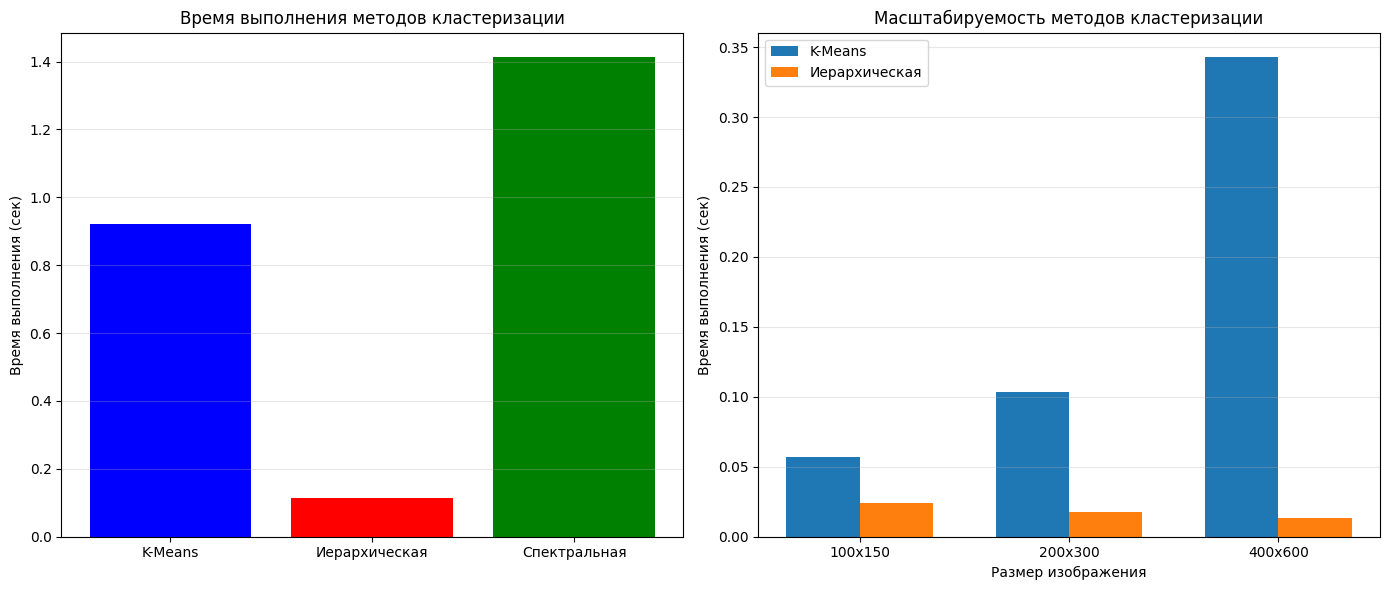

In [20]:
# ========================================
# ЧАСТЬ 2: Сравнение производительности методов
# ========================================

def compare_clustering_methods(img, K=4):
    """
    Сравнение производительности методов кластеризации
    """
    pixels = img.reshape(-1, 3).astype(np.float32)

    print("Сравнение производительности методов кластеризации (K=4)")
    print("=" * 60)

    results = {}

    # K-Means
    start_time = time.time()
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    ret, labels_km, centers_km = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    kmeans_time = time.time() - start_time

    results['K-Means'] = {
        'time': kmeans_time,
        'labels': labels_km,
        'inertia': ret
    }
    print(f"K-Means: время = {kmeans_time:.3f} сек, инерция = {ret:.2e}")

    # Иерархическая кластеризация (на подвыборке)
    sample_size = min(2000, len(pixels))
    sample_idx = np.random.choice(len(pixels), sample_size, replace=False)
    pixels_sample = pixels[sample_idx]

    start_time = time.time()
    Z = linkage(pixels_sample, method='ward')
    labels_hier = fcluster(Z, K, criterion='maxclust') - 1
    hierarchical_time = time.time() - start_time

    results['Иерархическая'] = {
        'time': hierarchical_time,
        'Z': Z,
        'sample_labels': labels_hier
    }
    print(f"Иерархическая: время = {hierarchical_time:.3f} сек")

    # Спектральная кластеризация (на подвыборке)
    spectral_sample_size = min(3000, len(pixels))
    sample_idx = np.random.choice(len(pixels), spectral_sample_size, replace=False)
    pixels_spectral_sample = pixels[sample_idx]

    start_time = time.time()
    spectral = SpectralClustering(n_clusters=K, affinity='rbf', gamma=0.001,
                                 random_state=42, n_init=3)
    labels_spectral = spectral.fit_predict(pixels_spectral_sample)
    spectral_time = time.time() - start_time

    results['Спектральная'] = {
        'time': spectral_time,
        'sample_labels': labels_spectral
    }
    print(f"Спектральная: время = {spectral_time:.3f} сек")

    return results

def test_scalability(img_sizes=[(100, 150), (200, 300), (400, 600)]):
    """
    Тестирование масштабируемости методов
    """
    print("\nТестирование масштабируемости методов")
    print("=" * 60)

    scalability_results = []

    for size in img_sizes:
        print(f"\nРазмер изображения: {size[0]}x{size[1]}")

        # Создаем изображение заданного размера
        img_test = np.zeros((size[0], size[1], 3), dtype=np.uint8)
        img_test[:, :] = [200, 150, 100]
        cv2.circle(img_test, (size[1]//4, size[0]//4), size[0]//8, (50, 50, 200), -1)
        cv2.circle(img_test, (3*size[1]//4, size[0]//4), size[0]//8, (50, 200, 50), -1)

        pixels = img_test.reshape(-1, 3).astype(np.float32)

        # Измеряем время для каждого метода
        start_time = time.time()
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        cv2.kmeans(pixels, 4, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
        kmeans_time = time.time() - start_time

        # Иерархическая (на подвыборке)
        sample_size = min(1000, len(pixels))
        sample_idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[sample_idx]

        start_time = time.time()
        linkage(pixels_sample, method='ward')
        hierarchical_time = time.time() - start_time

        scalability_results.append({
            'size': f"{size[0]}x{size[1]}",
            'pixels': size[0] * size[1],
            'kmeans_time': kmeans_time,
            'hierarchical_time': hierarchical_time
        })

        print(f"  Пикселей: {size[0]*size[1]}")
        print(f"  K-Means время: {kmeans_time:.3f} сек")
        print(f"  Иерархическая время: {hierarchical_time:.3f} сек")

    return scalability_results

# Выполнение сравнения
img = create_segmentation_test_image()
comparison_results = compare_clustering_methods(img)

# Тестирование масштабируемости
scalability_results = test_scalability()

# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График времени выполнения
methods = list(comparison_results.keys())
times = [comparison_results[m]['time'] for m in methods]

axes[0].bar(methods, times, color=['blue', 'red', 'green'])
axes[0].set_ylabel('Время выполнения (сек)')
axes[0].set_title('Время выполнения методов кластеризации')
axes[0].grid(True, alpha=0.3, axis='y')

# График масштабируемости
sizes = [r['size'] for r in scalability_results]
kmeans_times = [r['kmeans_time'] for r in scalability_results]
hier_times = [r['hierarchical_time'] for r in scalability_results]

x = np.arange(len(sizes))
width = 0.35

axes[1].bar(x - width/2, kmeans_times, width, label='K-Means')
axes[1].bar(x + width/2, hier_times, width, label='Иерархическая')
axes[1].set_xlabel('Размер изображения')
axes[1].set_ylabel('Время выполнения (сек)')
axes[1].set_title('Масштабируемость методов кластеризации')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sizes)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


1. Загрузка изображений...
Загружаем 1.jpg...
Загружаем 2.jpg...
Загружаем 3.jpg...

Загружено изображений: 3
  image_1: 867x1000 пикселей
  image_2: 612x384 пикселей
  image_3: 2000x1333 пикселей

2. Анализ изображений методами кластеризации...

Анализ изображения: image_1
--------------------------------------------------
Размер изображения: 346x400 пикселей
Применяем K-Means...
  K-Means: Silhouette score = 0.6041
Применяем иерархическую кластеризацию...
  Иерархическая: Silhouette score = 0.5941
Применяем спектральную кластеризацию...
  Спектральная: Silhouette score = 0.6017

Анализ изображения: image_2
--------------------------------------------------
Размер изображения: 400x250 пикселей
Применяем K-Means...
  K-Means: Silhouette score = 0.4640
Применяем иерархическую кластеризацию...
  Иерархическая: Silhouette score = 0.3895
Применяем спектральную кластеризацию...
  Спектральная: Silhouette score = 0.4168

Анализ изображения: image_3
------------------------------------------

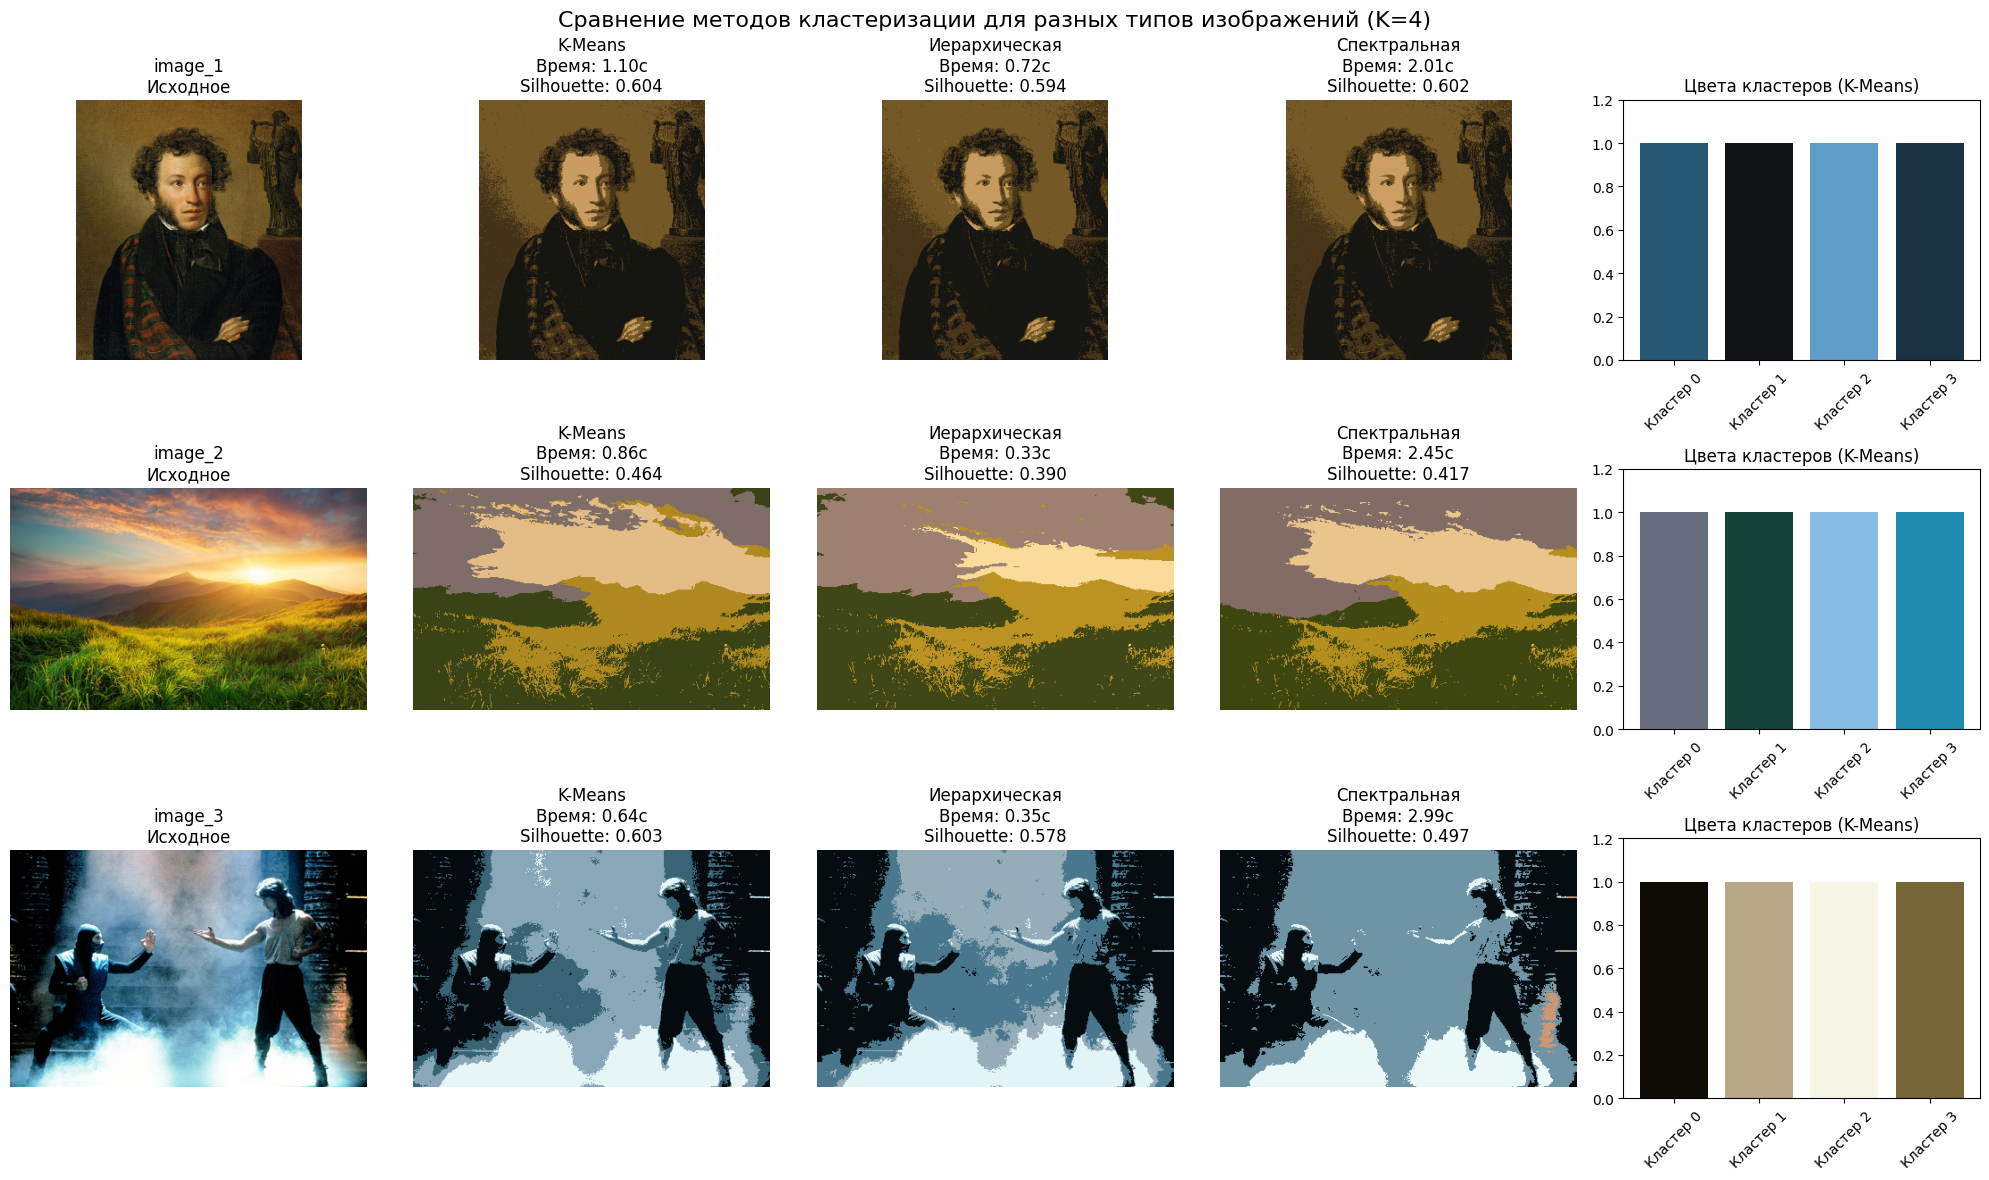


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Изображение     Метод           Время (с)    Silhouette   Инерция (K-Means)    Цвета кластеров               
----------------------------------------------------------------------------------------------------
image_1         K-Means         1.100        0.6041       4.64e+07             (38,88,116), (17,20,20), (97,1
image_1         Иерархическая   0.715        0.5941       -                    (96,155,198), (38,89,116), (25
image_1         Спектральная    2.009        0.6017       -                    (17,21,21), (99,158,203), (25,
----------------------------------------------------------------------------------------------------
image_2         K-Means         0.856        0.4640       2.11e+08             (103,109,127), (21,67,58), (13
image_2         Иерархическая   0.330        0.3895       -                    (22,71,63), (154,220,250), (35
image_2         Спектральная    2.455        0.4168       -                    (140,197,233), (15,70,62), (99

In [24]:
# ========================================
# ЧАСТЬ 3: Применение к реальным изображениям
# ========================================

import os
from sklearn.neighbors import NearestNeighbors

def load_or_create_images():
    """
    Загружает реальные изображения или создает синтетические, если файлы не найдены
    """
    image_paths = ['1.jpg', '2.jpg', '3.jpg']
    images = {}

    for i, path in enumerate(image_paths):
        if os.path.exists(path):
            # Загружаем реальное изображение
            print(f"Загружаем {path}...")
            img = cv2.imread(path)
            if img is None:
                print(f"Не удалось загрузить {path}, создаем синтетическое...")
                img = create_synthetic_image(i+1)
                cv2.imwrite(path, img)  # Сохраняем для будущего использования
            images[f'image_{i+1}'] = img
        else:
            # Создаем синтетическое изображение
            print(f"{path} не найден, создаем синтетическое изображение...")
            img = create_synthetic_image(i+1)
            cv2.imwrite(path, img)  # Сохраняем для будущего использования
            images[f'image_{i+1}'] = img

    return images

def create_synthetic_image(image_type):
    """
    Создает синтетические изображения для демонстрации
    image_type: 1 - портрет, 2 - пейзаж, 3 - сложная сцена
    """
    if image_type == 1:
        # Портрет (выделение кожи)
        img = np.zeros((400, 400, 3), dtype=np.uint8)
        # Фон
        img[:, :] = [200, 230, 250]
        # Кожа лица
        cv2.ellipse(img, (200, 150), (120, 150), 0, 0, 360, (180, 140, 120), -1)
        # Волосы
        cv2.ellipse(img, (200, 80), (100, 60), 0, 0, 360, (30, 20, 10), -1)
        # Глаза
        cv2.circle(img, (150, 140), 15, (255, 255, 255), -1)
        cv2.circle(img, (250, 140), 15, (255, 255, 255), -1)
        cv2.circle(img, (150, 140), 5, (0, 0, 0), -1)
        cv2.circle(img, (250, 140), 5, (0, 0, 0), -1)
        # Губы
        cv2.ellipse(img, (200, 220), (40, 20), 0, 0, 180, (150, 80, 100), -1)
        # Одежда
        cv2.rectangle(img, (100, 280), (300, 380), (100, 50, 150), -1)

    elif image_type == 2:
        # Пейзаж (выделение неба, земли)
        img = np.zeros((300, 500, 3), dtype=np.uint8)
        # Небо
        img[0:120, :] = [135, 206, 235]  # голубое
        # Солнце
        cv2.circle(img, (400, 80), 30, (255, 255, 100), -1)
        # Облака
        for x, y in [(100, 70), (200, 90), (300, 60)]:
            cv2.ellipse(img, (x, y), (40, 20), 0, 0, 360, (255, 255, 255), -1)
        # Горы
        mountain_color = (139, 137, 137)
        mountain_points = np.array([
            [0, 120], [100, 40], [200, 120], [300, 60], [400, 120], [500, 120]
        ], np.int32)
        cv2.fillPoly(img, [mountain_points], mountain_color)
        # Земля/трава
        img[120:, :] = [34, 139, 34]  # зеленый
        # Озеро
        cv2.ellipse(img, (250, 200), (80, 40), 0, 0, 360, (70, 130, 180), -1)

    else:  # image_type == 3
        # Сложная сцена
        img = np.zeros((400, 600, 3), dtype=np.uint8)
        # Фон (небо)
        img[0:200, :] = [135, 206, 235]
        # Здание
        cv2.rectangle(img, (100, 100), (300, 300), (139, 69, 19), -1)  # коричневое
        # Окна
        for i in range(3):
            for j in range(4):
                x = 120 + j * 40
                y = 120 + i * 50
                cv2.rectangle(img, (x, y), (x+25, y+35), (255, 255, 200), -1)
        # Дорога
        cv2.rectangle(img, (0, 300), (600, 400), (105, 105, 105), -1)
        # Разметка
        for i in range(0, 600, 80):
            cv2.rectangle(img, (i, 350), (i+40, 355), (255, 255, 0), -1)
        # Машины
        cv2.rectangle(img, (150, 280), (250, 300), (220, 20, 60), -1)  # красная
        cv2.rectangle(img, (350, 290), (450, 310), (30, 30, 180), -1)  # синяя
        # Деревья
        for x, y in [(50, 150), (500, 150), (550, 180)]:
            cv2.rectangle(img, (x, y), (x+10, y+50), (101, 67, 33), -1)
            cv2.circle(img, (x+5, y-20), 40, (0, 100, 0), -1)

    # Добавляем небольшой шум для реалистичности
    noise = np.random.randint(-10, 10, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

def preprocess_image(img, max_size=400):
    """
    Предобработка изображения: изменение размера и нормализация
    """
    # Изменяем размер для ускорения обработки
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        new_w = int(w * scale)
        new_h = int(h * scale)
        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Преобразуем в RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img, img_rgb

def apply_kmeans_to_image(img, K=4):
    """
    Применение K-Means к изображению
    """
    pixels = img.reshape(-1, 3).astype(np.float32)

    # Применяем K-Means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    ret, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

    # Создаем сегментированное изображение
    centers = centers.astype(np.uint8)
    segmented = centers[labels.flatten()].reshape(img.shape)

    return segmented, labels.flatten(), centers, ret

def apply_hierarchical_to_image(img, K=4, sample_size=2000):
    """
    Применение иерархической кластеризации к изображению
    """
    pixels = img.reshape(-1, 3).astype(np.float32)

    # Используем подвыборку для скорости
    if len(pixels) > sample_size:
        sample_idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[sample_idx]
    else:
        pixels_sample = pixels

    # Применяем иерархическую кластеризацию
    Z = linkage(pixels_sample, method='ward')
    labels_sample = fcluster(Z, K, criterion='maxclust') - 1

    # Распространяем на все пиксели
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(pixels_sample)
    distances, indices = nn.kneighbors(pixels)
    labels = labels_sample[indices.flatten()]

    # Вычисляем центры кластеров
    centers = np.array([np.mean(pixels[labels == k], axis=0) for k in range(K)]).astype(np.uint8)
    segmented = centers[labels].reshape(img.shape)

    return segmented, labels, centers, Z

def apply_spectral_to_image(img, K=4, sample_size=3000, sigma=10.0):
    """
    Применение спектральной кластеризации к изображению
    """
    pixels = img.reshape(-1, 3).astype(np.float32)

    # Используем подвыборку для скорости
    if len(pixels) > sample_size:
        sample_idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[sample_idx]
    else:
        pixels_sample = pixels

    # Применяем спектральную кластеризацию
    spectral = SpectralClustering(n_clusters=K, affinity='rbf', gamma=1/(2*sigma**2),
                                 random_state=42, n_init=3)
    labels_sample = spectral.fit_predict(pixels_sample)

    # Распространяем на все пиксели
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(pixels_sample)
    distances, indices = nn.kneighbors(pixels)
    labels = labels_sample[indices.flatten()]

    # Вычисляем центры кластеров
    centers = np.array([np.mean(pixels[labels == k], axis=0) for k in range(K)]).astype(np.uint8)
    segmented = centers[labels].reshape(img.shape)

    return segmented, labels, centers, sigma

def evaluate_segmentation_quality(img, labels, method_name):
    """
    Оценка качества сегментации
    """
    pixels = img.reshape(-1, 3).astype(np.float32)

    # Вычисляем silhouette score (на подвыборке для скорости)
    sample_size = min(1000, len(pixels))
    if len(pixels) > sample_size:
        sample_idx = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[sample_idx]
        labels_sample = labels[sample_idx]
    else:
        pixels_sample = pixels
        labels_sample = labels

    from sklearn.metrics import silhouette_score
    try:
        score = silhouette_score(pixels_sample, labels_sample)
    except:
        score = silhouette_score_manual(pixels_sample, labels_sample)

    print(f"  {method_name}: Silhouette score = {score:.4f}")
    return score

def analyze_segmentation_results(img, img_name, K=4):
    """
    Применяет все методы кластеризации к изображению и анализирует результаты
    """
    print(f"\nАнализ изображения: {img_name}")
    print("-" * 50)

    # Предобработка изображения
    img_processed, img_rgb = preprocess_image(img)
    h, w = img_processed.shape[:2]
    print(f"Размер изображения: {w}x{h} пикселей")

    results = {}

    # Применяем K-Means
    print("Применяем K-Means...")
    start_time = time.time()
    segmented_km, labels_km, centers_km, inertia = apply_kmeans_to_image(img_processed, K)
    km_time = time.time() - start_time
    km_score = evaluate_segmentation_quality(img_processed, labels_km, "K-Means")

    results['K-Means'] = {
        'image': segmented_km,
        'time': km_time,
        'silhouette': km_score,
        'centers': centers_km,
        'inertia': inertia
    }

    # Применяем иерархическую кластеризацию
    print("Применяем иерархическую кластеризацию...")
    start_time = time.time()
    segmented_hi, labels_hi, centers_hi, Z = apply_hierarchical_to_image(img_processed, K)
    hi_time = time.time() - start_time
    hi_score = evaluate_segmentation_quality(img_processed, labels_hi, "Иерархическая")

    results['Иерархическая'] = {
        'image': segmented_hi,
        'time': hi_time,
        'silhouette': hi_score,
        'centers': centers_hi,
        'Z': Z
    }

    # Применяем спектральную кластеризацию
    print("Применяем спектральную кластеризацию...")
    start_time = time.time()
    segmented_sp, labels_sp, centers_sp, sigma = apply_spectral_to_image(img_processed, K)
    sp_time = time.time() - start_time
    sp_score = evaluate_segmentation_quality(img_processed, labels_sp, "Спектральная")

    results['Спектральная'] = {
        'image': segmented_sp,
        'time': sp_time,
        'silhouette': sp_score,
        'centers': centers_sp,
        'sigma': sigma
    }

    return img_rgb, results

def visualize_results_comparison(images_data):
    """
    Визуализация сравнения результатов для всех изображений
    """
    n_images = len(images_data)

    fig, axes = plt.subplots(n_images, 5, figsize=(20, 4*n_images))

    if n_images == 1:
        axes = axes.reshape(1, -1)

    for i, (img_name, (img_rgb, results)) in enumerate(images_data.items()):
        row = i

        # Исходное изображение
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f'{img_name}\nИсходное')
        axes[row, 0].axis('off')

        # K-Means результат
        axes[row, 1].imshow(cv2.cvtColor(results['K-Means']['image'], cv2.COLOR_BGR2RGB))
        axes[row, 1].set_title(f"K-Means\nВремя: {results['K-Means']['time']:.2f}с\nSilhouette: {results['K-Means']['silhouette']:.3f}")
        axes[row, 1].axis('off')

        # Иерархический результат
        axes[row, 2].imshow(cv2.cvtColor(results['Иерархическая']['image'], cv2.COLOR_BGR2RGB))
        axes[row, 2].set_title(f"Иерархическая\nВремя: {results['Иерархическая']['time']:.2f}с\nSilhouette: {results['Иерархическая']['silhouette']:.3f}")
        axes[row, 2].axis('off')

        # Спектральный результат
        axes[row, 3].imshow(cv2.cvtColor(results['Спектральная']['image'], cv2.COLOR_BGR2RGB))
        axes[row, 3].set_title(f"Спектральная\nВремя: {results['Спектральная']['time']:.2f}с\nSilhouette: {results['Спектральная']['silhouette']:.3f}")
        axes[row, 3].axis('off')

        # Цвета кластеров (для K-Means как примера)
        axes[row, 4].bar(range(len(results['K-Means']['centers'])), [1]*len(results['K-Means']['centers']),
                        color=results['K-Means']['centers']/255)
        axes[row, 4].set_title('Цвета кластеров (K-Means)')
        axes[row, 4].set_xticks(range(len(results['K-Means']['centers'])))
        axes[row, 4].set_xticklabels([f'Кластер {i}' for i in range(len(results['K-Means']['centers']))], rotation=45)
        axes[row, 4].set_ylabel('')
        axes[row, 4].set_ylim([0, 1.2])

    plt.suptitle('Сравнение методов кластеризации для разных типов изображений (K=4)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Вывод сводной таблицы
    print("\n" + "="*100)
    print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
    print("="*100)
    print(f"{'Изображение':<15} {'Метод':<15} {'Время (с)':<12} {'Silhouette':<12} {'Инерция (K-Means)':<20} {'Цвета кластеров':<30}")
    print("-"*100)

    for img_name, (img_rgb, results) in images_data.items():
        for method in ['K-Means', 'Иерархическая', 'Спектральная']:
            method_data = results[method]

            if method == 'K-Means':
                colors_str = ', '.join([f'({c[0]},{c[1]},{c[2]})' for c in method_data['centers']])
                inertia_str = f"{method_data.get('inertia', 0):.2e}"
            else:
                colors_str = ', '.join([f'({c[0]},{c[1]},{c[2]})' for c in method_data['centers']])
                inertia_str = "-"

            print(f"{img_name:<15} {method:<15} {method_data['time']:<12.3f} {method_data['silhouette']:<12.4f} {inertia_str:<20} {colors_str[:30]:<30}")
        print("-"*100)

# Основной код для части 3
# Загружаем или создаем изображения
print("\n1. Загрузка изображений...")
images_dict = load_or_create_images()

print(f"\nЗагружено изображений: {len(images_dict)}")
for name, img in images_dict.items():
    print(f"  {name}: {img.shape[1]}x{img.shape[0]} пикселей")

# Анализируем каждое изображение
print("\n2. Анализ изображений методами кластеризации...")
all_results = {}

for img_name, img in images_dict.items():
    img_rgb, results = analyze_segmentation_results(img, img_name, K=4)
    all_results[img_name] = (img_rgb, results)

# Визуализируем сравнение результатов
print("\n3. Визуализация результатов...")
visualize_results_comparison(all_results)